# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
a bad intermediate is caught immediately — before moving to the next cell —
rather than discovered in a final artifact.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    retrend,
    subset_space,
)
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "tas"
ENSEMBLE_MEMBER = "001"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "SSP245"

# Cape Town / Western Cape — 4°×4°, ~16 coarse cells, fast for interactive use.
# (lat_min, lat_max, lon_min, lon_max)
SUBSET_BOUNDS = (-34.0, -30.0, 18.0, 22.0)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")

Run: CESM2-WACCM_tas_001_SSP245_subset
Subset bounds: (-34.0, -30.0, 18.0, 22.0)
Scenario: 'SSP245'
Predict period: 2015–2060


## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [3]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.



  obs_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 17, 'lon': 17}
  NaN:   0.0000 (0.00%)


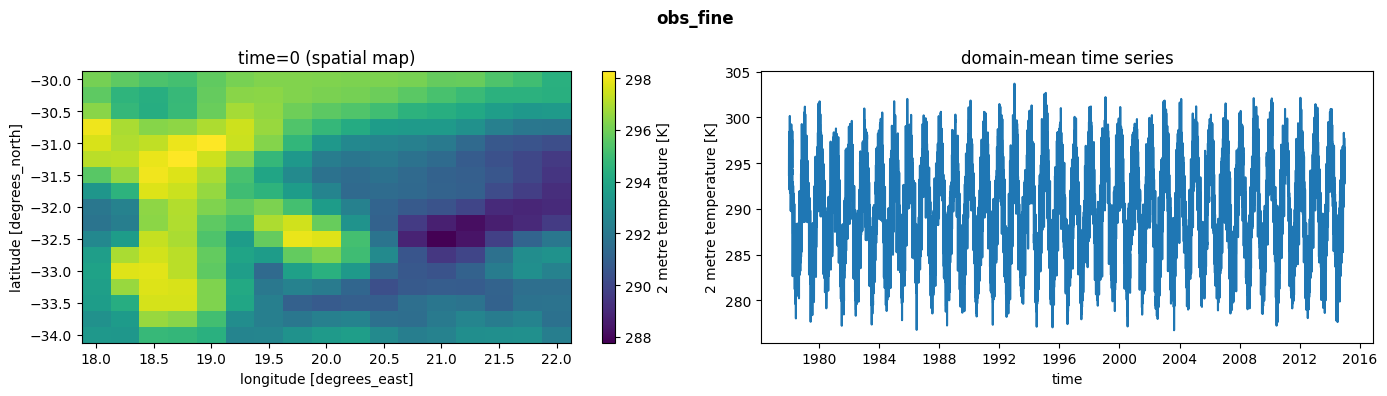

In [4]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
obs_fine = inspect(obs_fine, "obs_fine")


  model_grid
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


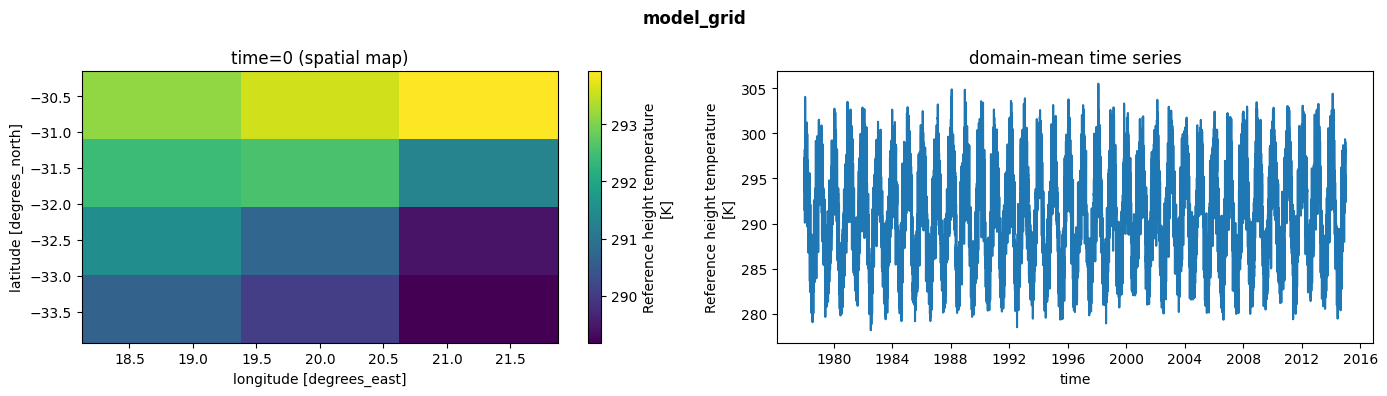

In [5]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)
model_grid = inspect(model_grid, "model_grid")


  obs_coarse_stage1
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


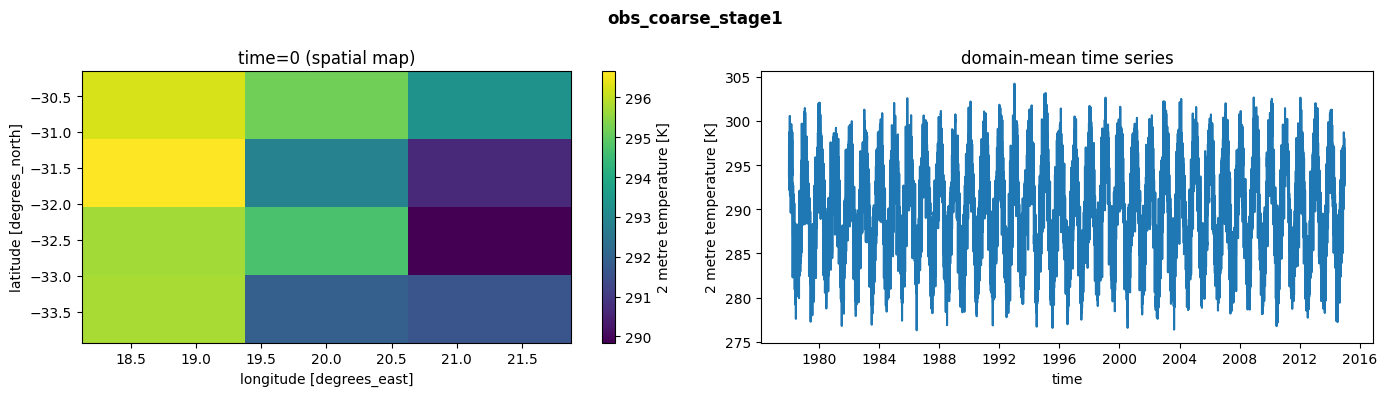

In [6]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [7]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...
  2026-06-25T23:52:09.368357Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-25T23:52:09.703238Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-34.0to-30.0_lon18.0to22.0.icechunk
CPU times: user 3min 27s, sys: 1min 32s, total: 5min
Wall time: 3min 49s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


  2026-06-25T23:55:59.045513Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-25T23:55:59.046216Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196


  obs_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


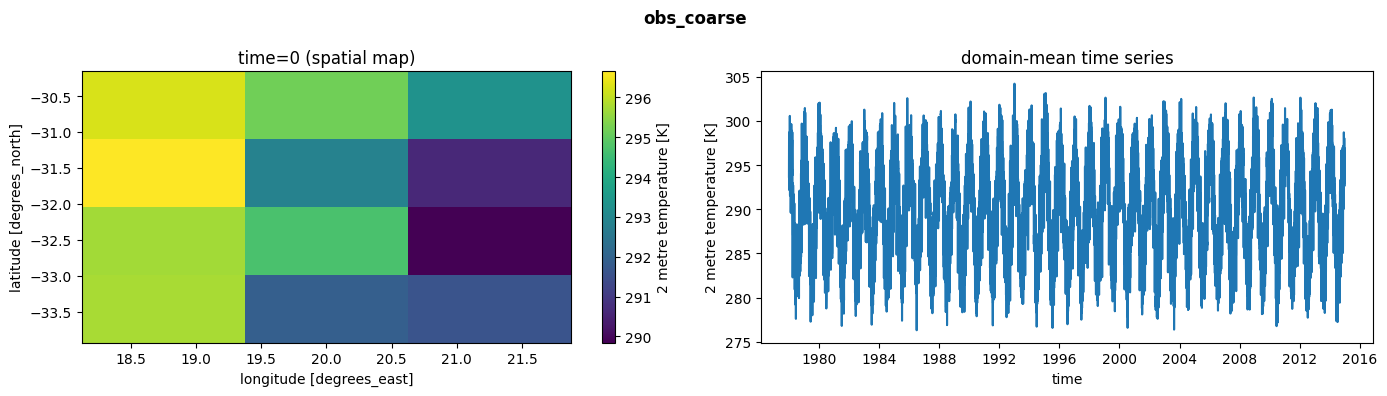


  obs_fine_s2
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 17, 'lon': 17}
  NaN:   0.0000 (0.00%)


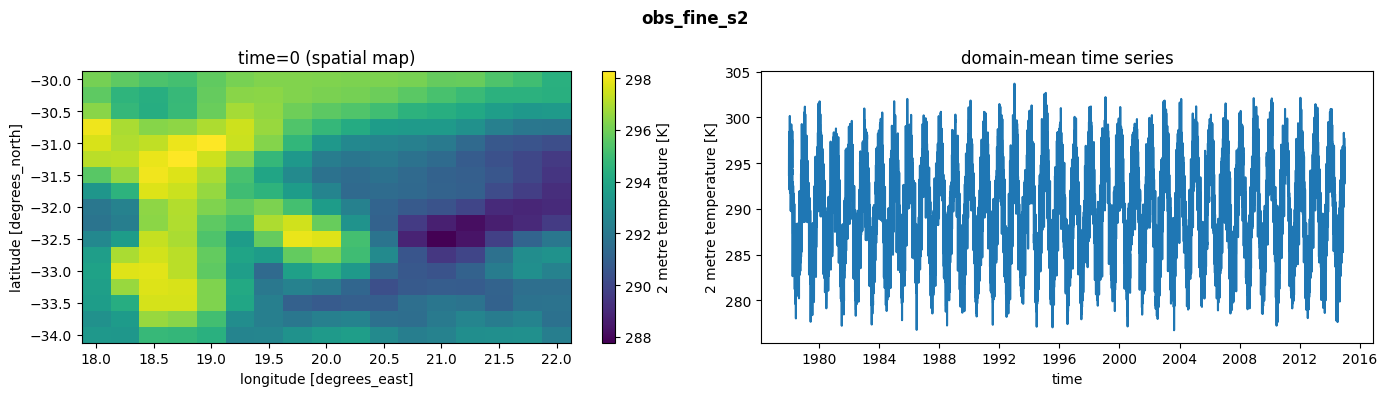


  model_hist
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


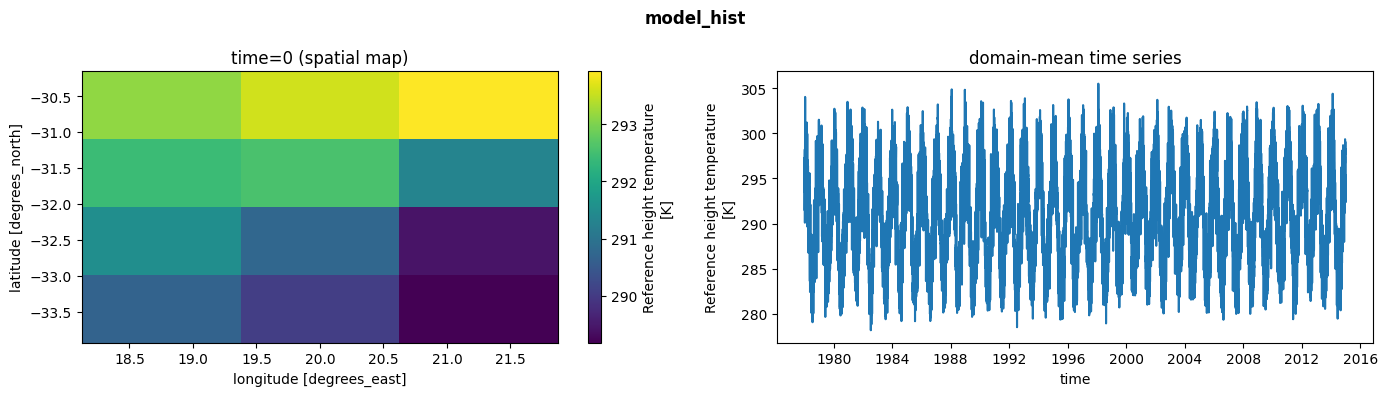

CPU times: user 1min 57s, sys: 52.3 s, total: 2min 50s
Wall time: 1min 53s


In [8]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
obs_coarse = inspect(obs_coarse, "obs_coarse")
obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
model_hist = inspect(model_hist, "model_hist")


  debiased_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


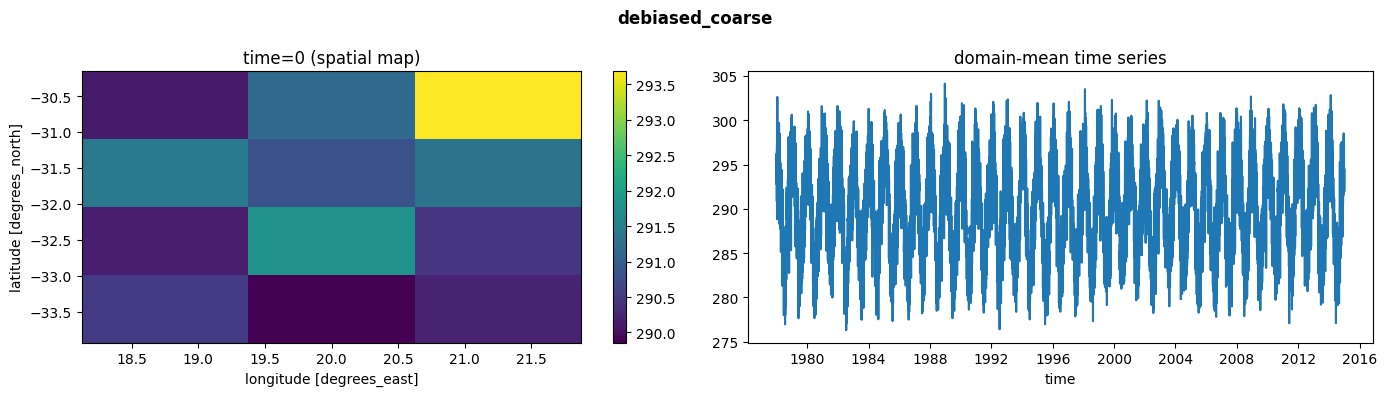

CPU times: user 221 ms, sys: 158 ms, total: 379 ms
Wall time: 726 ms


In [9]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

### Spatial disaggregation sub-steps (Stage 2)

The single `_apply_spatial_downscaling()` call is expanded into five named
intermediates (Cells A–E) plus a consistency check (Cell F), so each step
can be inspected independently. These mirror the internals of
`downscale_from_coarse()` exactly.

> **Cell A** and **Cell B** compute the obs climatology, which is
> scenario-independent. The arrays will be reused in Stage 3 (starting from
> Cell C) so those cells do not need to rerun them.



  obs_fine_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 17, 'lon': 17}
  NaN:   0.0000 (0.00%)


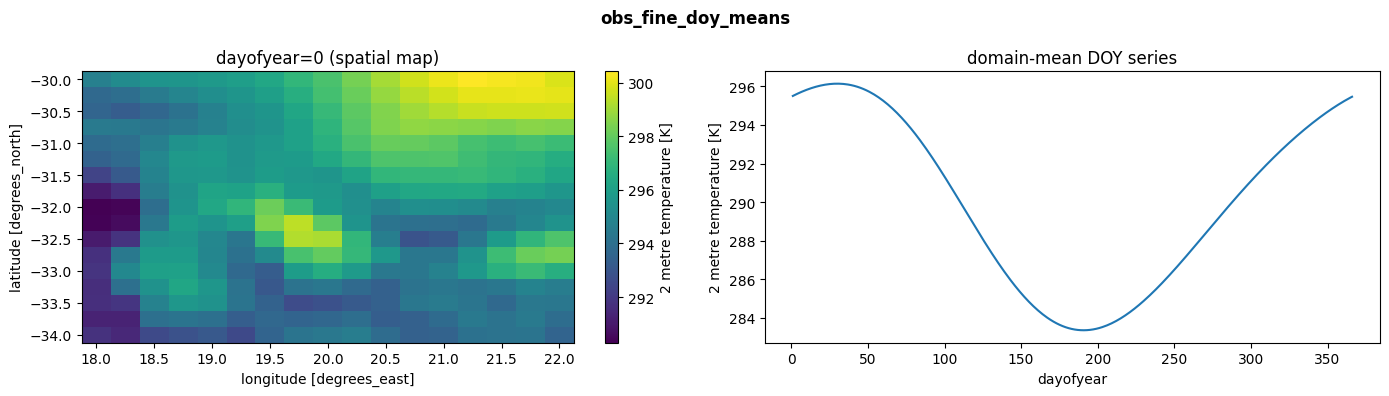

CPU times: user 447 ms, sys: 5.3 ms, total: 453 ms
Wall time: 442 ms


In [10]:
%%time
# ── Cell A: fine-grid day-of-year climatology ──────────────────────────────────
# Uses the downscaling_clim_method from config (typically "fft" for most vars).
obs_fine_doy_means = calculate_doy_means(obs_fine_s2, clim_method=config.downscaling_clim_method)
obs_fine_doy_means = inspect(obs_fine_doy_means, "obs_fine_doy_means")

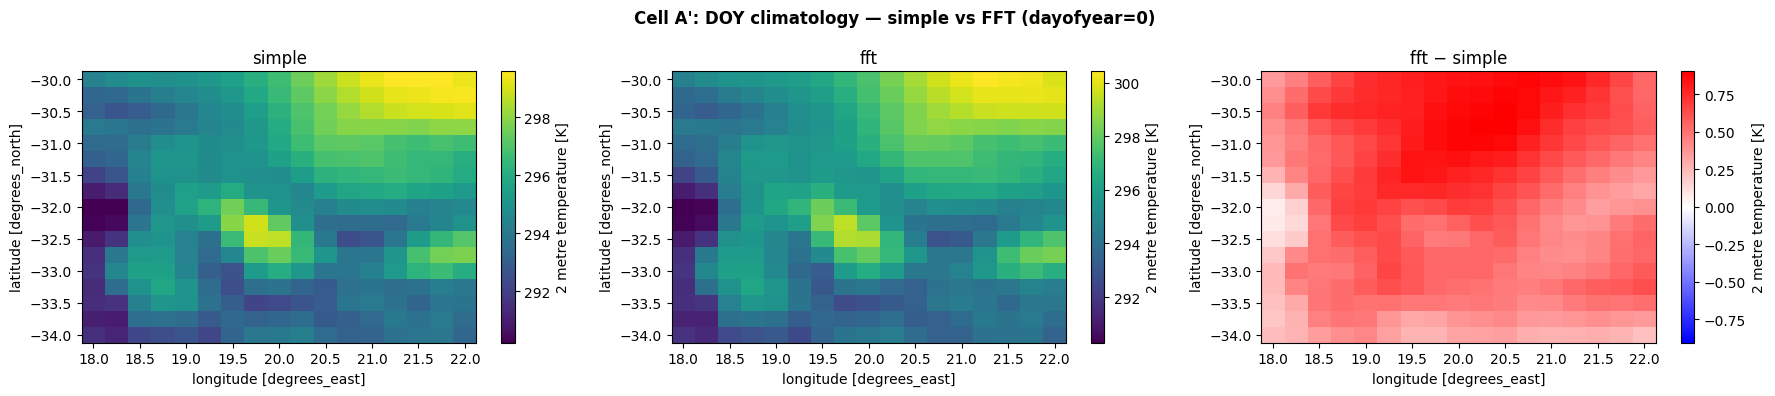

CPU times: user 301 ms, sys: 9.39 ms, total: 310 ms
Wall time: 296 ms


In [11]:
%%time
# ── Cell A': FFT vs simple climatology comparison ─────────────────────────────
# Three-panel map: simple | fft | diff (bwr, center=0) for dayofyear=0.
# Reveals FFT-smoothing artifacts found in prior QA notebooks.
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple")
obs_fine_doy_means_fft = calculate_doy_means(obs_fine_s2, clim_method="fft")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cell A': DOY climatology — simple vs FFT (dayofyear=0)", fontweight="bold")
kw = dict(add_colorbar=True)
obs_fine_doy_means_simple.isel(dayofyear=0).plot(ax=axes[0], **kw)
axes[0].set_title("simple")
obs_fine_doy_means_fft.isel(dayofyear=0).plot(ax=axes[1], **kw)
axes[1].set_title("fft")
diff = (obs_fine_doy_means_fft - obs_fine_doy_means_simple).isel(dayofyear=0)
diff.plot(ax=axes[2], cmap="bwr", center=0, **kw)
axes[2].set_title("fft − simple")
plt.tight_layout()
plt.show()


  obs_coarse_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


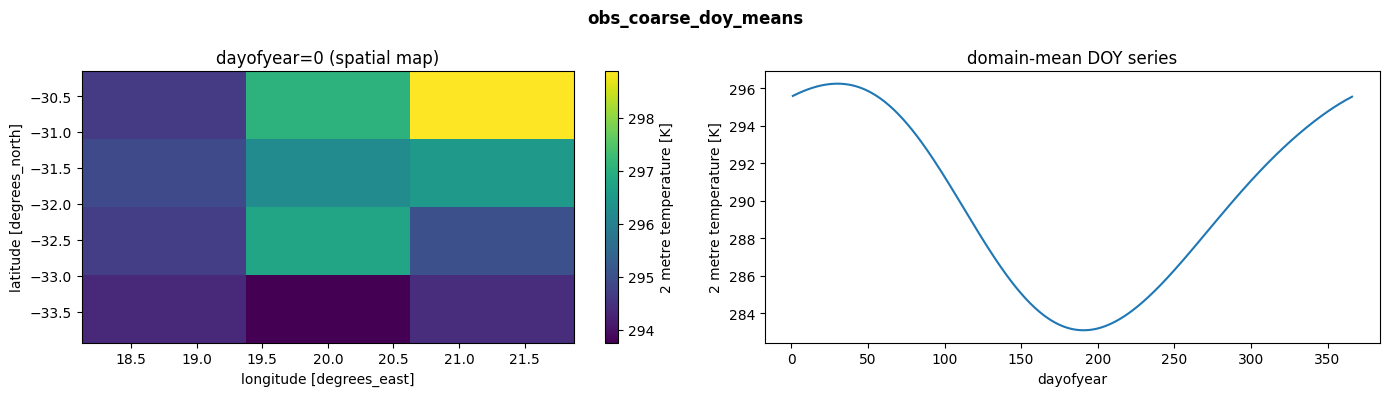

In [12]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
)
obs_coarse_doy_means = inspect(obs_coarse_doy_means, "obs_coarse_doy_means")


  residuals_coarse
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 100.00% of values outside [100, 400]
        out_of_range_fraction: 1.0
        actual_min: -13.5877685546875
        actual_max: 14.603179931640625
        expected_min: 100
        expected_max: 400
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


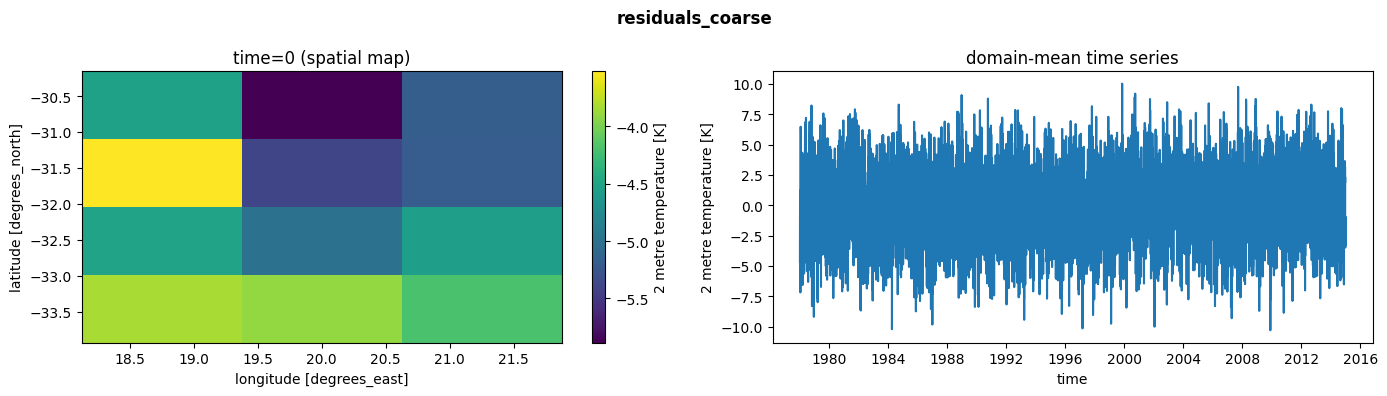

In [13]:
# ── Cell C: coarse spatial residuals (debiased − coarse climatology) ──────────
if config.downscaling_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.downscaling_method == "multiplicative":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / obs_coarse_doy_means
residuals_coarse = inspect(residuals_coarse, "residuals_coarse")


  residuals_fine
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 100.00% of values outside [100, 400]
        out_of_range_fraction: 1.0
        actual_min: -13.566892623901367
        actual_max: 14.57254409790039
        expected_min: 100
        expected_max: 400
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 17, 'lon': 17}
  NaN:   0.5813 (58.13%)


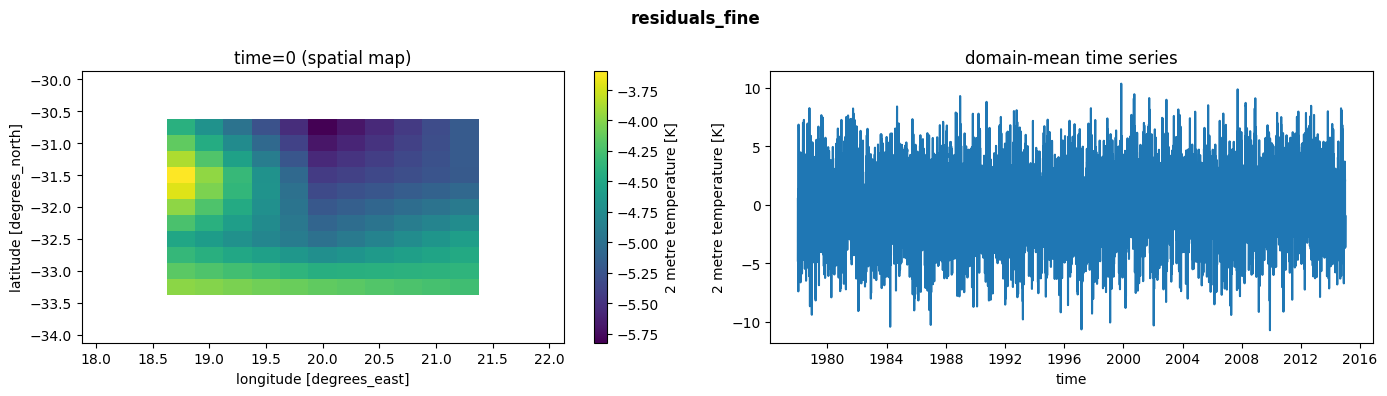

In [14]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse, da_fine_grid=obs_fine_s2
)
residuals_fine = inspect(residuals_fine, "residuals_fine")


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 17, 'lon': 17}
  NaN:   0.5813 (58.13%)


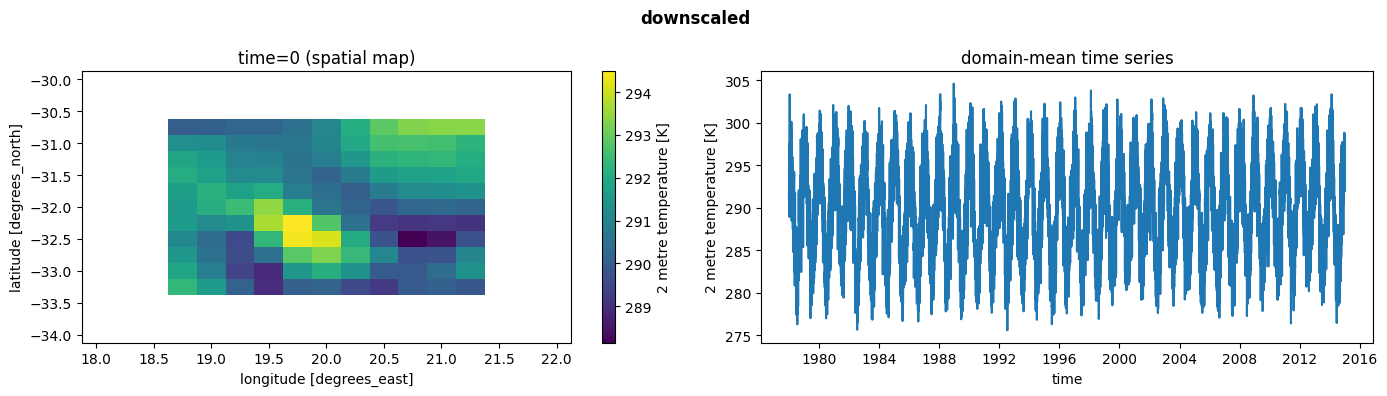

In [15]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.downscaling_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    downscaled = residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
downscaled = inspect(downscaled, "downscaled")

In [16]:
%%time
# ── Cell F: consistency check vs production downscale_from_coarse() ───────────
# Fails loudly if step-by-step result diverges from the production function.
ref = downscale_from_coarse(
    da=debiased_coarse,
    obs_coarse=obs_coarse,
    obs_fine=obs_fine_s2,
    method=config.downscaling_method,
    clim_method=config.downscaling_clim_method,
).compute()

match = np.allclose(downscaled.values, ref.values, equal_nan=True)
print(f"Consistency check (Cell F): {'PASS ✓' if match else 'FAIL ✗'}")
assert match, (
    "Step-by-step result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

Consistency check (Cell F): PASS ✓
CPU times: user 69.6 ms, sys: 2.62 ms, total: 72.3 ms
Wall time: 62.9 ms


In [17]:
# ── Optional: write historical to debug cache for Stage 3 ─────────────────────
# Only needed if you plan to run Stage 3 cells below.  Uncomment and run.
# print("Writing fit_historical to debug cache ...")
# hist_path = pipeline.fit_historical(force=True)
# print(f"  → {hist_path}")


### tasmin special path

If `VARIABLE == "tasmin"`, `fit_historical_tasmin` / `transform_scenario_tasmin`
compute `tasmin = debiased_tasmax − debiased_dtr` instead of debiasing tasmin
directly. To debug that path:

1. Run `fit_historical(force=True)` for **dtr** and **tasmax** with
   `save_intermediate=True` (so the debiased intermediates are written to the
   debug cache).
2. Then load them:
   ```python
   if config.variable == "tasmin":
       debiased_dtr_loc = pipeline.cache.debiased_historical_loc(
           pipeline._hist_member, variable="dtr"
       )
       debiased_tasmax_loc = pipeline.cache.debiased_historical_loc(
           pipeline._hist_member, variable="tasmax"
       )
       debiased_dtr = pipeline._open_from_icechunk(debiased_dtr_loc)["dtr"]
       debiased_tasmax = pipeline._open_from_icechunk(debiased_tasmax_loc)["tasmax"]
       debiased_tasmin = debiased_tasmax - debiased_dtr
       debiased_tasmin = inspect(debiased_tasmin, "debiased_tasmin_from_dtr")
       # then run _apply_spatial_downscaling and inspect as above
   ```


## Stage 3 — `transform_scenario`

Cells below run only when `SCENARIO` is set in the config cell. Run
`pipeline.fit_historical(force=True)` (the optional cell at the end of
Stage 2) before executing these cells, so the historical artifact exists in
the debug cache and `_load_scenario_data()` can validate its dependency.


In [18]:
if config.scenario is None:
    raise RuntimeError(
        "SCENARIO is None. Set SCENARIO in the config cell and re-run "
        "from the top before executing Stage 3 cells."
    )

  2026-06-25T23:57:55.035782Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-25T23:57:55.036549Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-25T23:57:55.037095Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196


  obs_coarse_s3
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


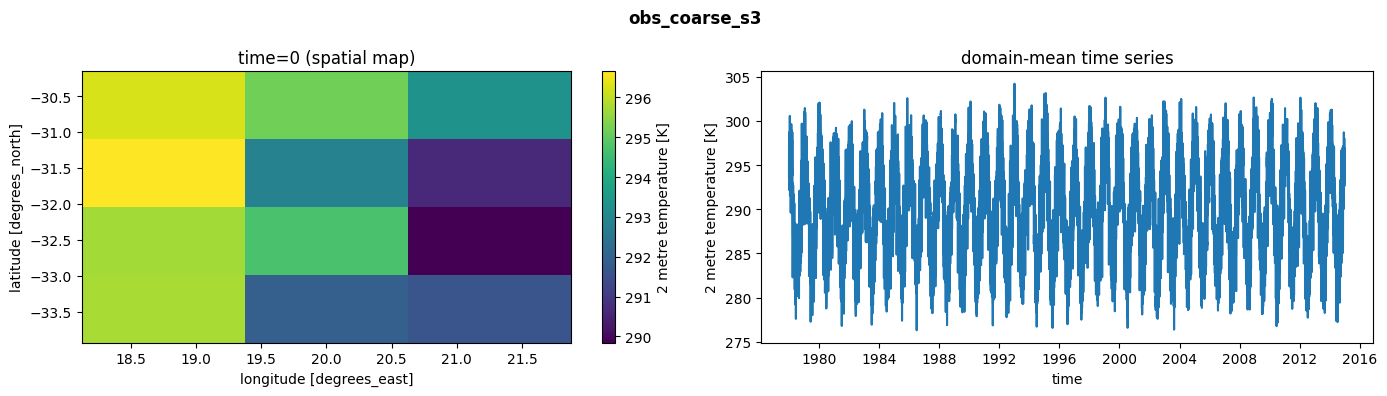


  obs_fine_s3
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 17, 'lon': 17}
  NaN:   0.0000 (0.00%)


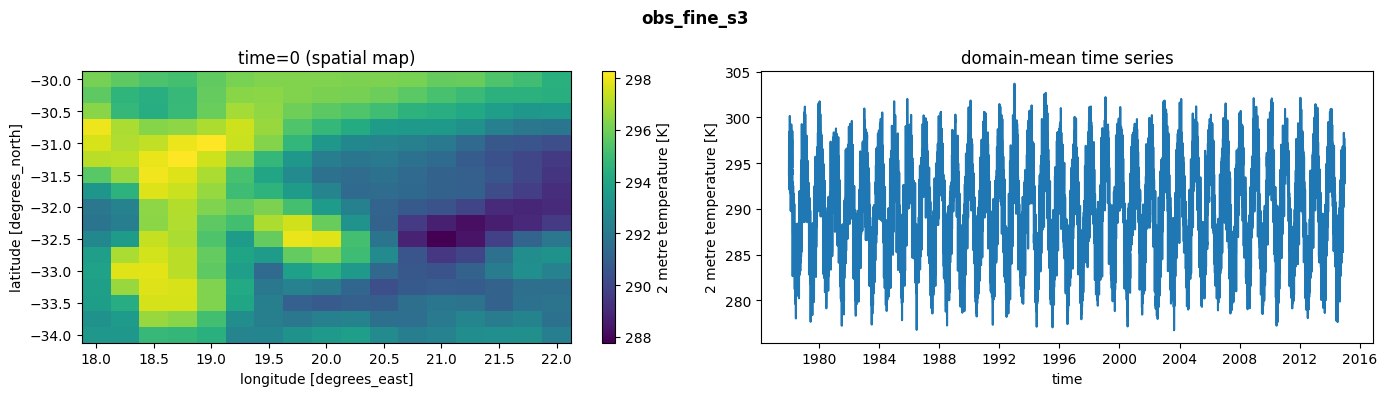


  model_hist_s3
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


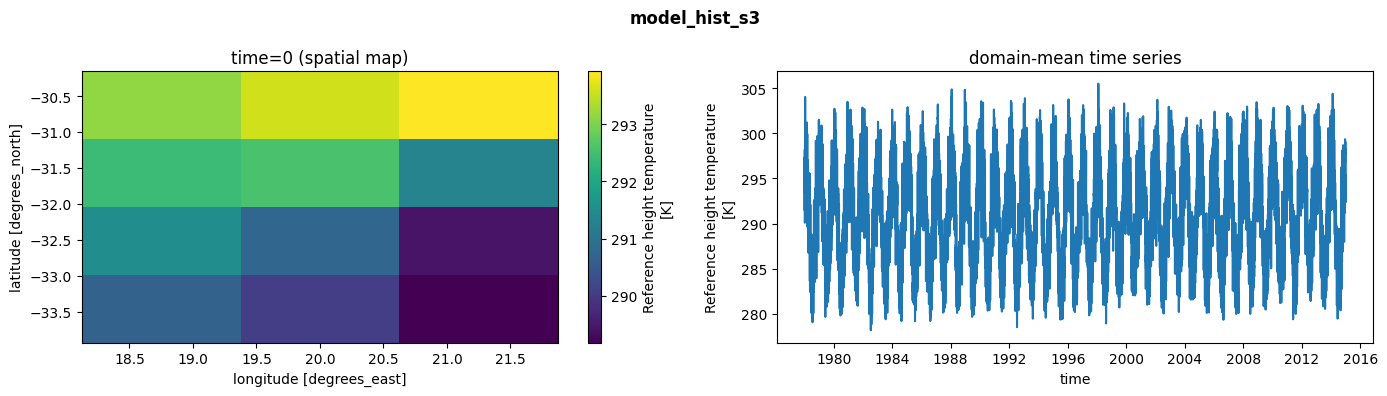


  model_scenario
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


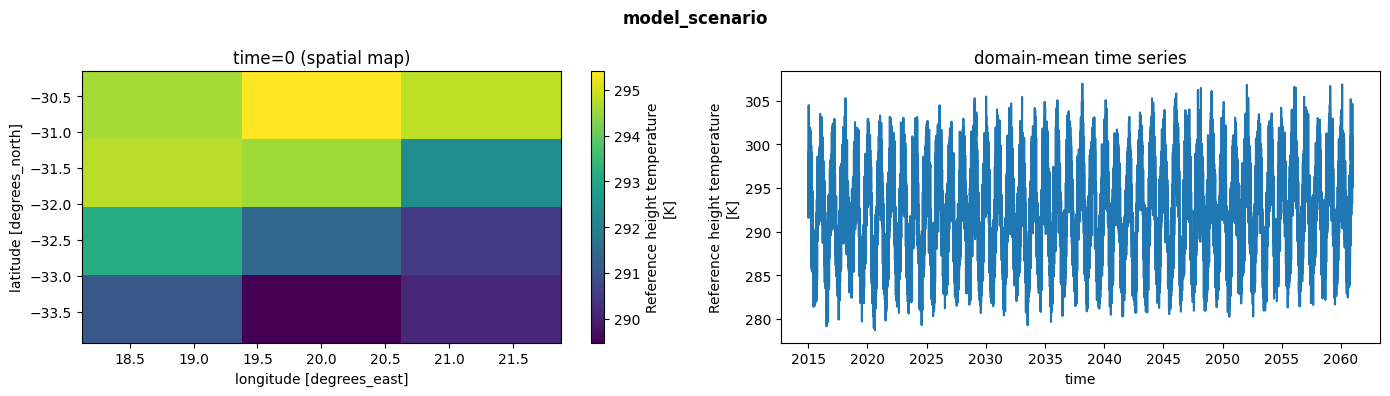

CPU times: user 2min 4s, sys: 54.4 s, total: 2min 58s
Wall time: 1min 59s


In [19]:
%%time
# ── _load_scenario_data ────────────────────────────────────────────────────────
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()

obs_coarse_s3 = inspect(obs_coarse_s3, "obs_coarse_s3")
obs_fine_s3 = inspect(obs_fine_s3, "obs_fine_s3")
model_hist_s3 = inspect(model_hist_s3, "model_hist_s3")
model_scenario = inspect(model_scenario, "model_scenario")
if ssp_timeseries is not None:
    ssp_timeseries = inspect(ssp_timeseries, "ssp_timeseries")


  scenario_detrended
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


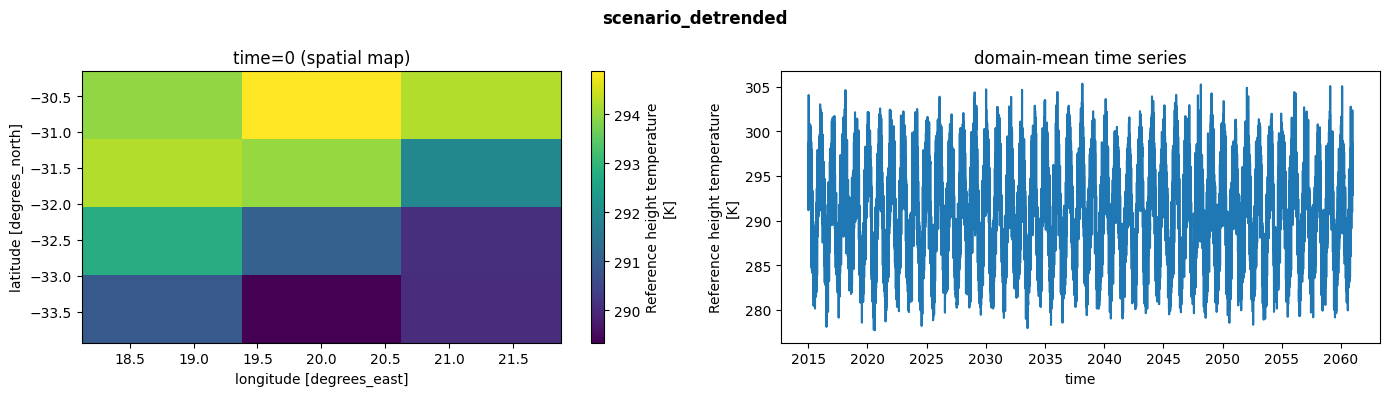


  scenario_trend
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 100.00% of values outside [100, 400]
        out_of_range_fraction: 1.0
        actual_min: -0.24139404296875
        actual_max: 5.262786865234375
        expected_min: 100
        expected_max: 400
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


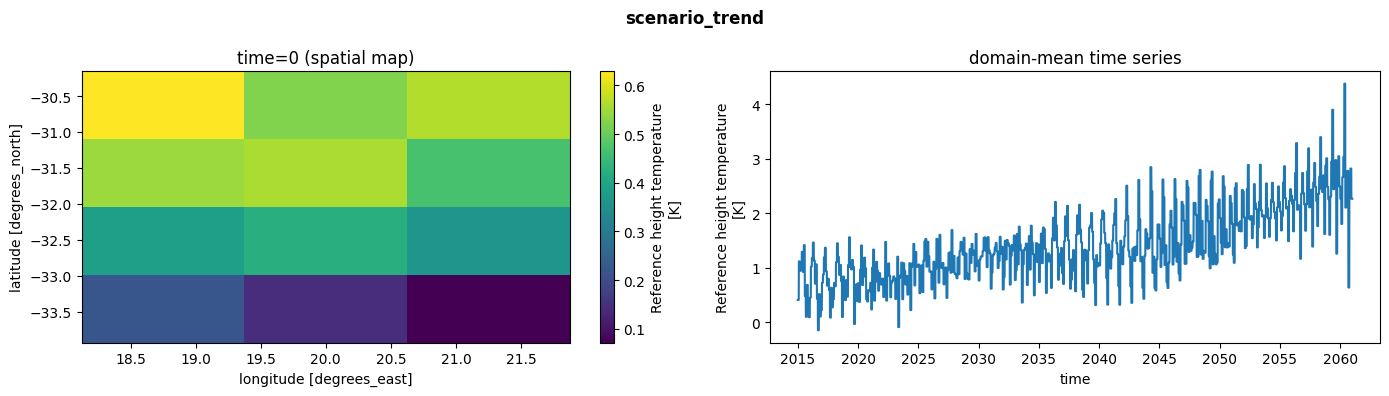

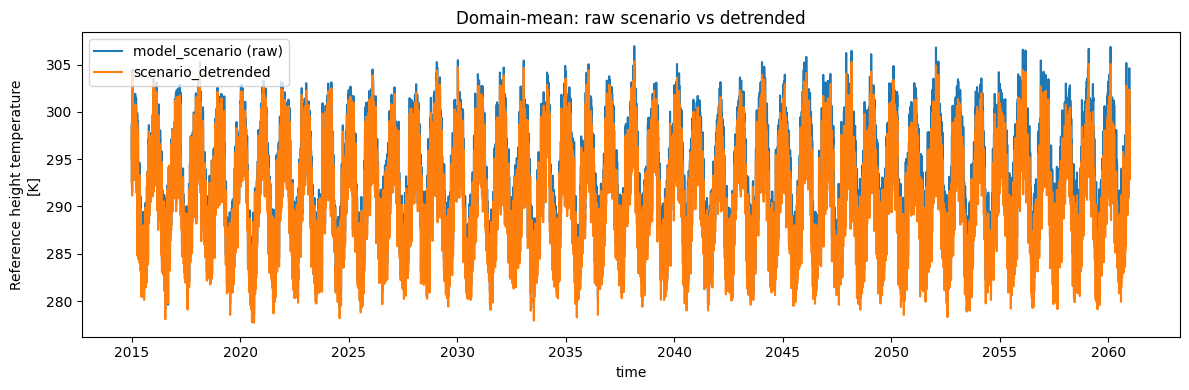

In [20]:
# ── _detrend_scenario ──────────────────────────────────────────────────────────
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)
scenario_detrended = inspect(scenario_detrended, "scenario_detrended")
if scenario_trend is not None:
    scenario_trend = inspect(scenario_trend, "scenario_trend")

# Visual comparison: detrended vs raw scenario to confirm detrending direction.
fig, ax = plt.subplots(figsize=(12, 4))
model_scenario.mean(["lat", "lon"]).plot(ax=ax, label="model_scenario (raw)")
scenario_detrended.mean(["lat", "lon"]).plot(ax=ax, label="scenario_detrended")
ax.legend()
ax.set_title("Domain-mean: raw scenario vs detrended")
plt.tight_layout()
plt.show()


  scenario_debiased
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


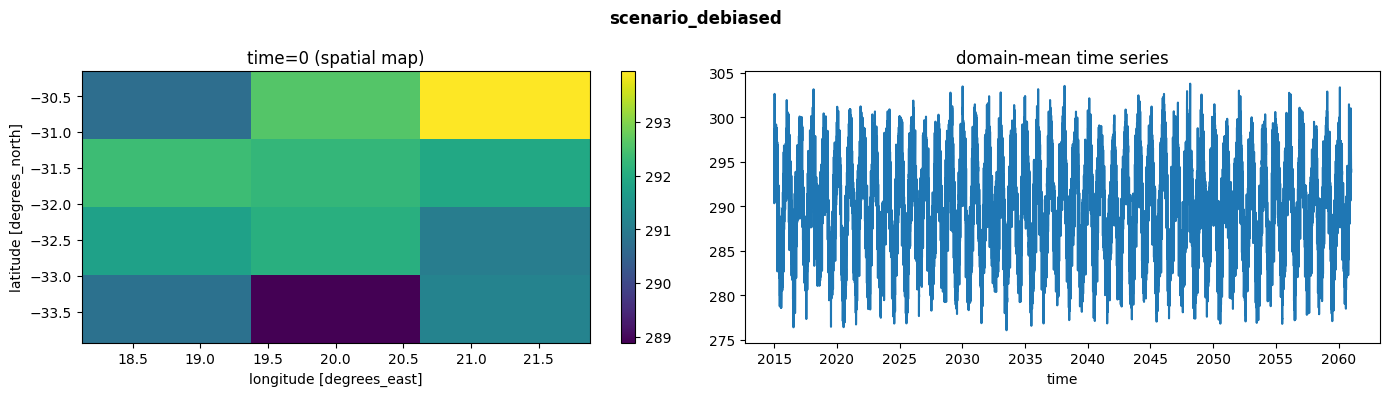

CPU times: user 2.35 s, sys: 458 ms, total: 2.81 s
Wall time: 3.61 s


In [21]:
%%time
# ── _apply_bias_correction_scenario ───────────────────────────────────────────
scenario_debiased = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended
)
scenario_debiased = inspect(scenario_debiased, "scenario_debiased")


  scenario_debiased_retrended
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


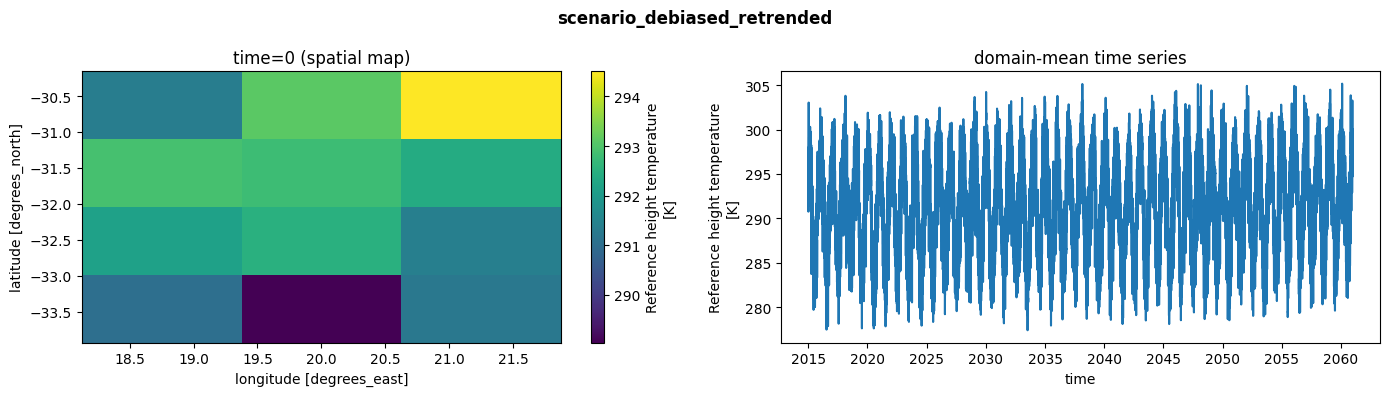

In [22]:
# ── retrend (only if scenario_trend exists) ───────────────────────────────────
if scenario_trend is not None:
    scenario_debiased = retrend(scenario_debiased, scenario_trend, config.detrend_method)
    scenario_debiased = inspect(scenario_debiased, "scenario_debiased_retrended")
else:
    print("No trend to reapply (detrend_data=False for this variable).")

### Scenario spatial disaggregation sub-steps

Cells A and B (obs climatology) were already computed in Stage 2 as
`obs_fine_doy_means` and `obs_coarse_doy_means`. Reuse them here; start from
Cell C.



  scenario_residuals_coarse
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 100.00% of values outside [100, 400]
        out_of_range_fraction: 1.0
        actual_min: -12.78955078125
        actual_max: 17.605377197265625
        expected_min: 100
        expected_max: 400
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 4, 'lon': 3}
  NaN:   0.0000 (0.00%)


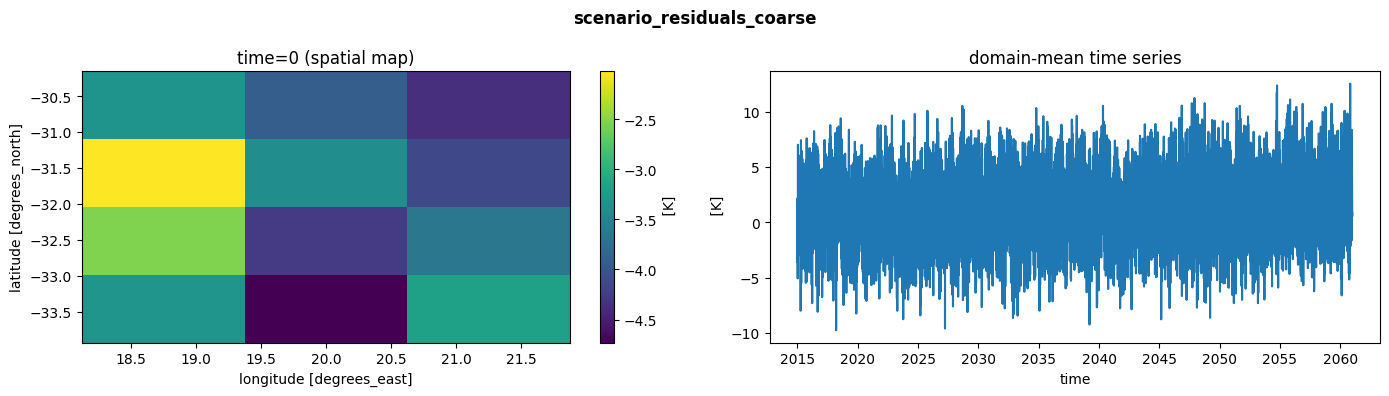

In [23]:
# ── Cell C (scenario): coarse spatial residuals ───────────────────────────────
if config.downscaling_method == "additive":
    scenario_residuals_coarse = scenario_debiased.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.downscaling_method == "multiplicative":
    scenario_residuals_coarse = scenario_debiased.groupby("time.dayofyear") / obs_coarse_doy_means
scenario_residuals_coarse = inspect(scenario_residuals_coarse, "scenario_residuals_coarse")


  scenario_residuals_fine
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 100.00% of values outside [100, 400]
        out_of_range_fraction: 1.0
        actual_min: -12.712145805358887
        actual_max: 17.14381217956543
        expected_min: 100
        expected_max: 400
  ✗ sporadic_nan_days: FAIL — 16802 time steps have partial NaN coverage
        sporadic_nan_day_count: 16802
        sample_dates: ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05']
  shape: {'time': 16802, 'lat': 17, 'lon': 17}
  NaN:   0.5813 (58.13%)


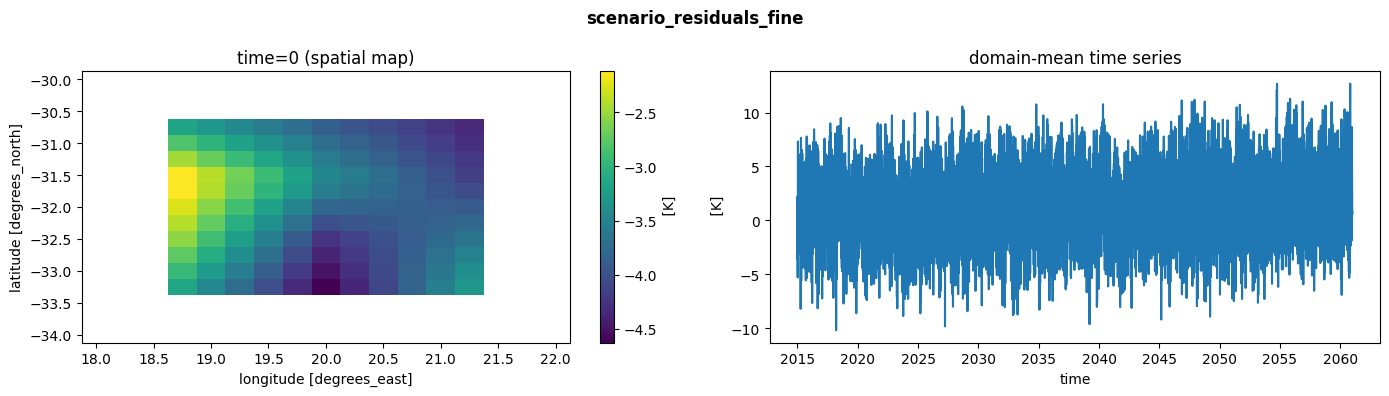

In [24]:
# ── Cell D (scenario): interpolate residuals to fine grid ─────────────────────
# NaN introduced here (interpolation step) vs Cell E (climatology add-back)
# becomes immediately visible as a jump in nan_fraction.
scenario_residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=scenario_residuals_coarse, da_fine_grid=obs_fine_s3
)
scenario_residuals_fine = inspect(scenario_residuals_fine, "scenario_residuals_fine")


  scenario_downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 16802 time steps have partial NaN coverage
        sporadic_nan_day_count: 16802
        sample_dates: ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05']
  shape: {'time': 16802, 'lat': 17, 'lon': 17}
  NaN:   0.5813 (58.13%)


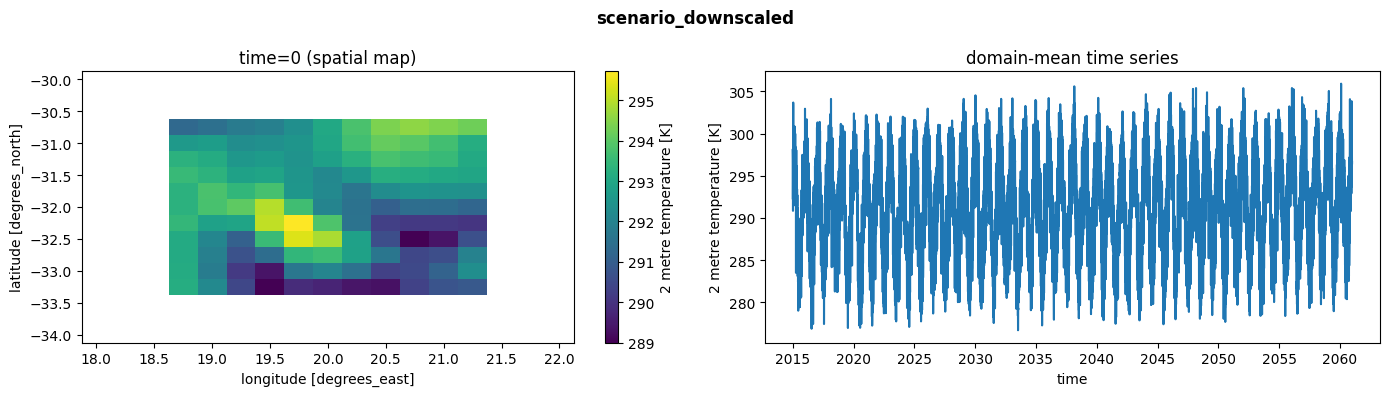

In [25]:
# ── Cell E (scenario): reapply fine-grid DOY climatology ──────────────────────
if config.downscaling_method == "additive":
    scenario_downscaled = scenario_residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    scenario_downscaled = scenario_residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
scenario_downscaled = inspect(scenario_downscaled, "scenario_downscaled")

In [26]:
%%time
# ── Cell F (scenario): consistency check vs production downscale_from_coarse() ─
ref_scenario = downscale_from_coarse(
    da=scenario_debiased,
    obs_coarse=obs_coarse_s3,
    obs_fine=obs_fine_s3,
    method=config.downscaling_method,
    clim_method=config.downscaling_clim_method,
).compute()

match_s3 = np.allclose(scenario_downscaled.values, ref_scenario.values, equal_nan=True)
print(f"Consistency check (Cell F, scenario): {'PASS ✓' if match_s3 else 'FAIL ✗'}")
assert match_s3, (
    "Step-by-step scenario result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

Consistency check (Cell F, scenario): PASS ✓
CPU times: user 76.9 ms, sys: 9.37 ms, total: 86.3 ms
Wall time: 78.4 ms


In [27]:
# ── Ocean mask (only if apply_ocean_mask is enabled) ─────────────────────────
if options.apply_ocean_mask:
    mask = pipeline._build_ocean_mask(scenario_downscaled)
    land_frac = float(mask.mean())
    print(f"Ocean mask land coverage: {land_frac:.2%}")
    mask.plot(figsize=(8, 4))
    plt.title("Ocean mask (True = land)")
    plt.show()

    scenario_downscaled_masked = scenario_downscaled.where(mask)
    scenario_downscaled_masked = inspect(scenario_downscaled_masked, "scenario_downscaled_masked")
else:
    print("apply_ocean_mask=False — skipping ocean mask step.")

apply_ocean_mask=False — skipping ocean mask step.


## Cross-stage evolution plots

Re-run this section at any point — it iterates over whatever is in `STEPS`
so far. Four complementary views:

1. **Faceted spatial maps** — shared and per-panel colour scales
2. **Overlaid domain-mean time series** — reveals trend/level shifts
3. **Overlaid value distributions** — shows how bias-correction reshapes tails
4. **NaN-fraction bar chart** — one glance to see where NaNs first appear


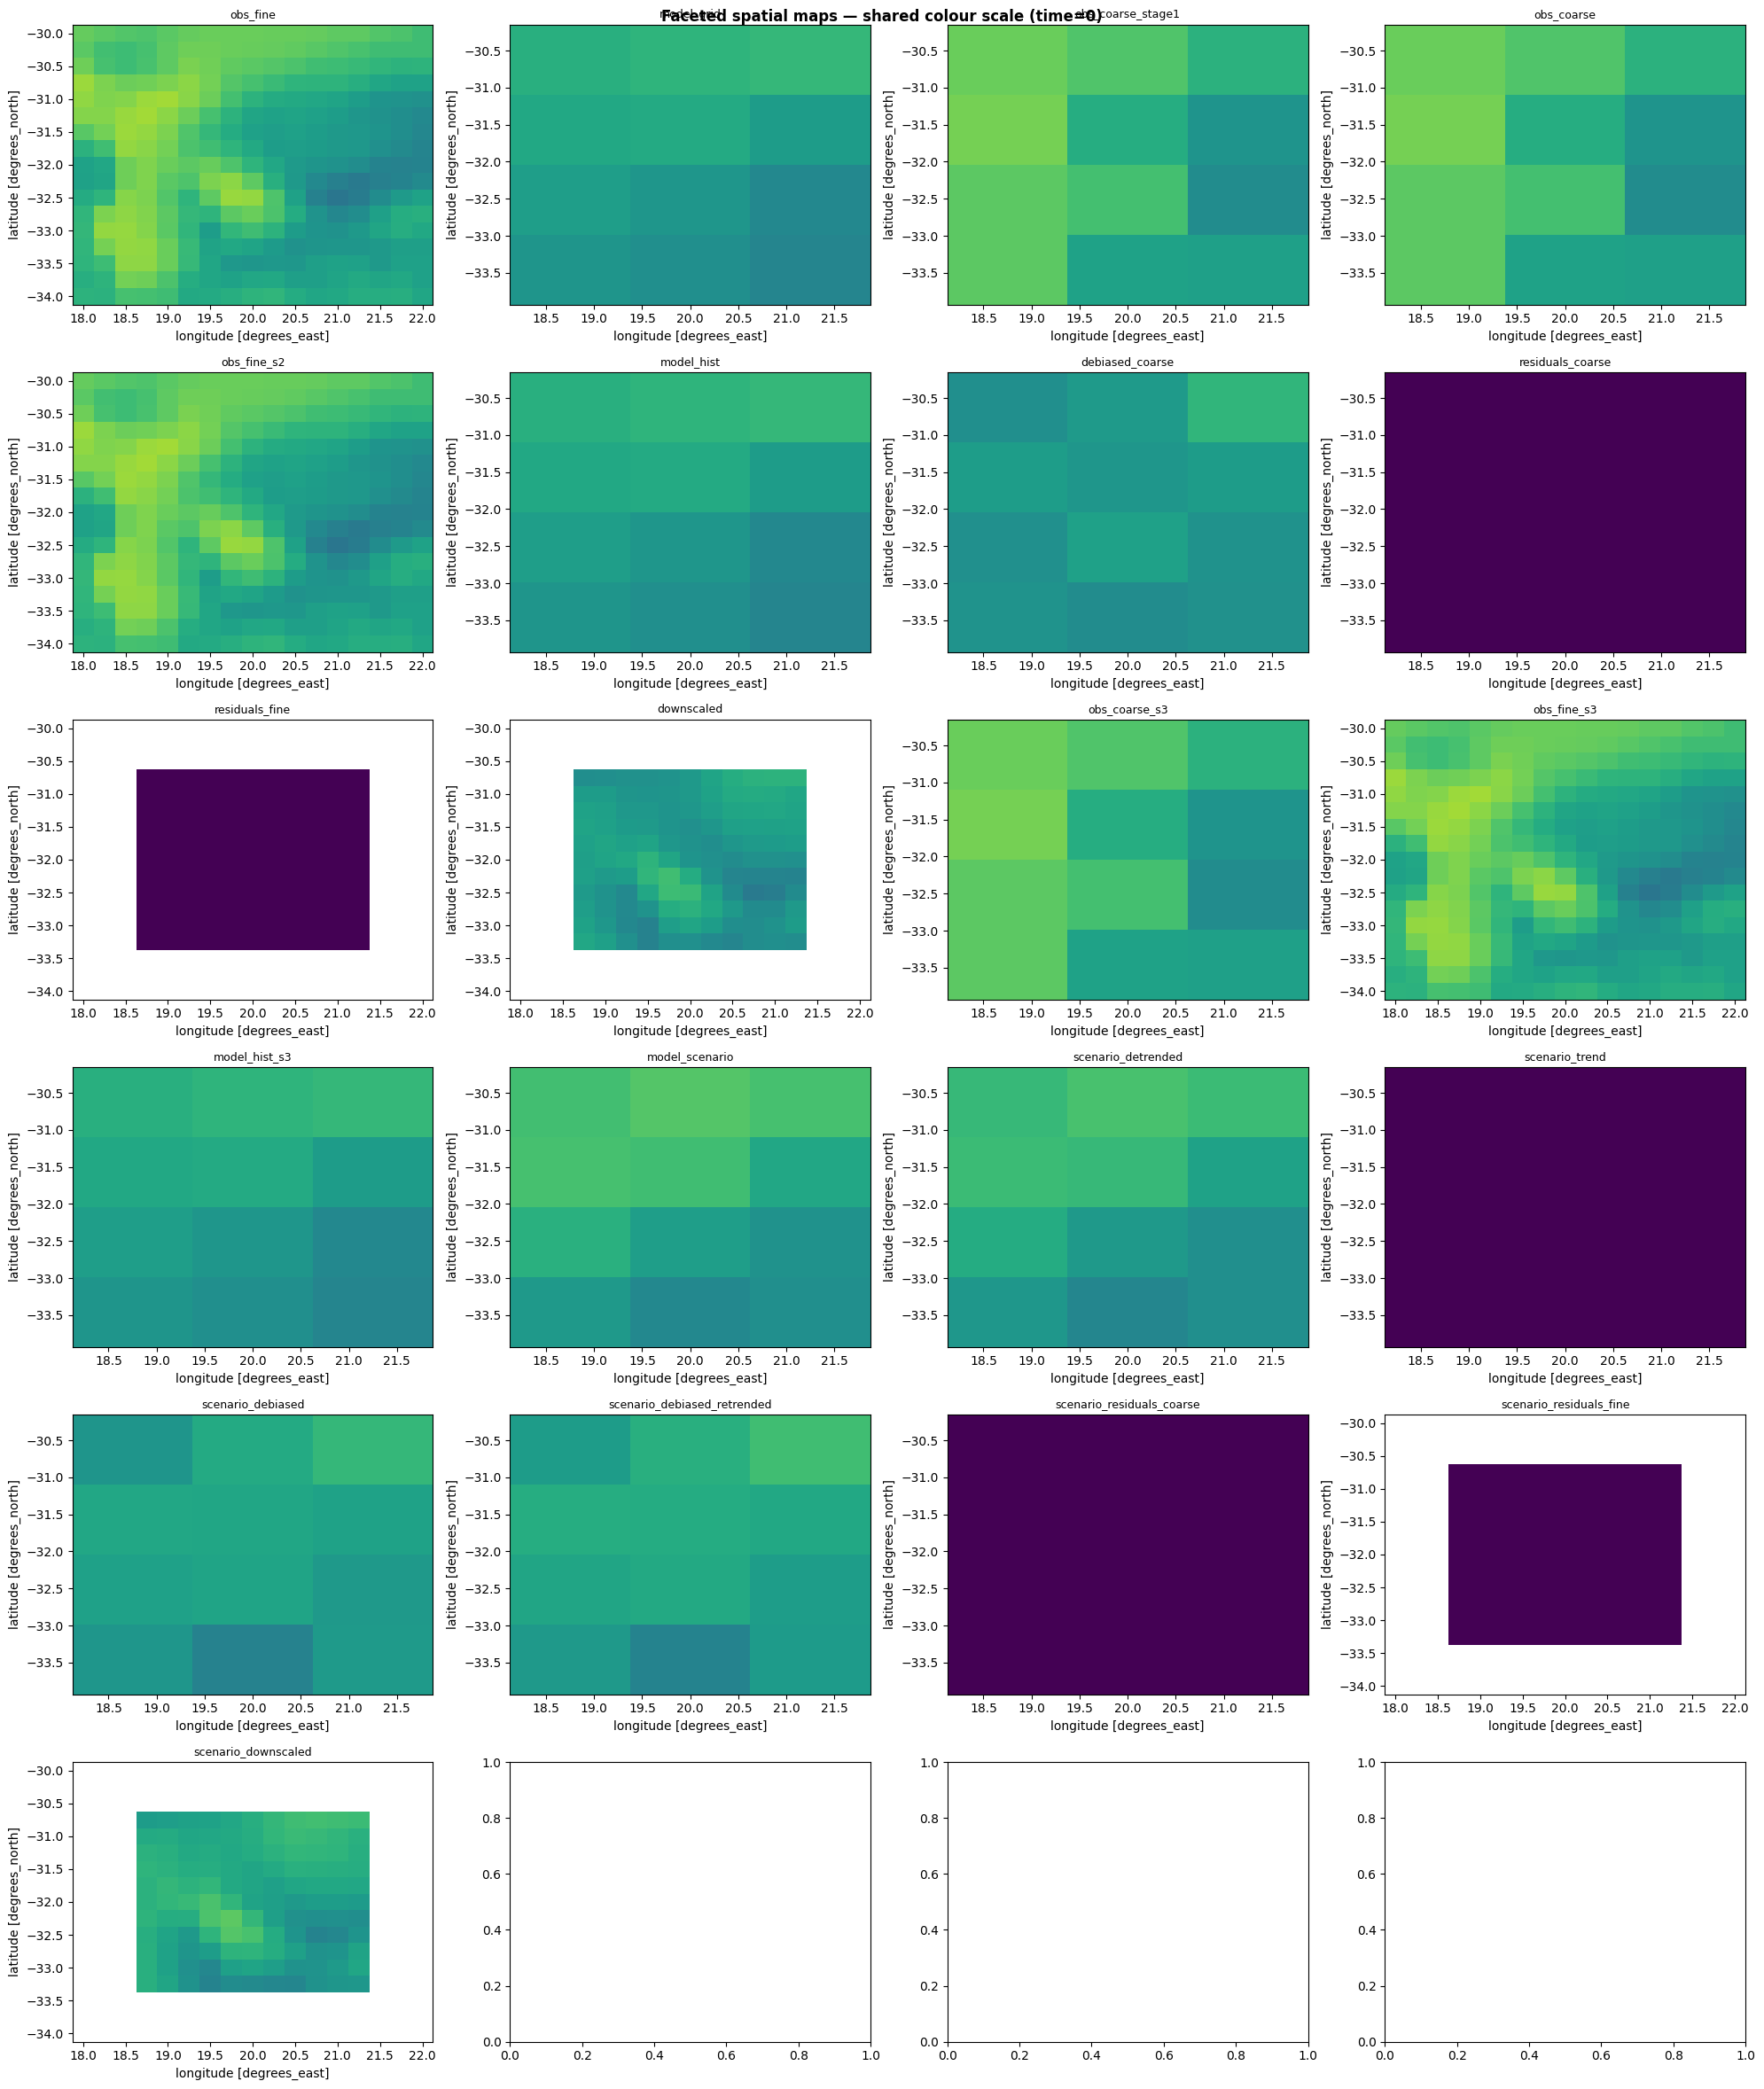

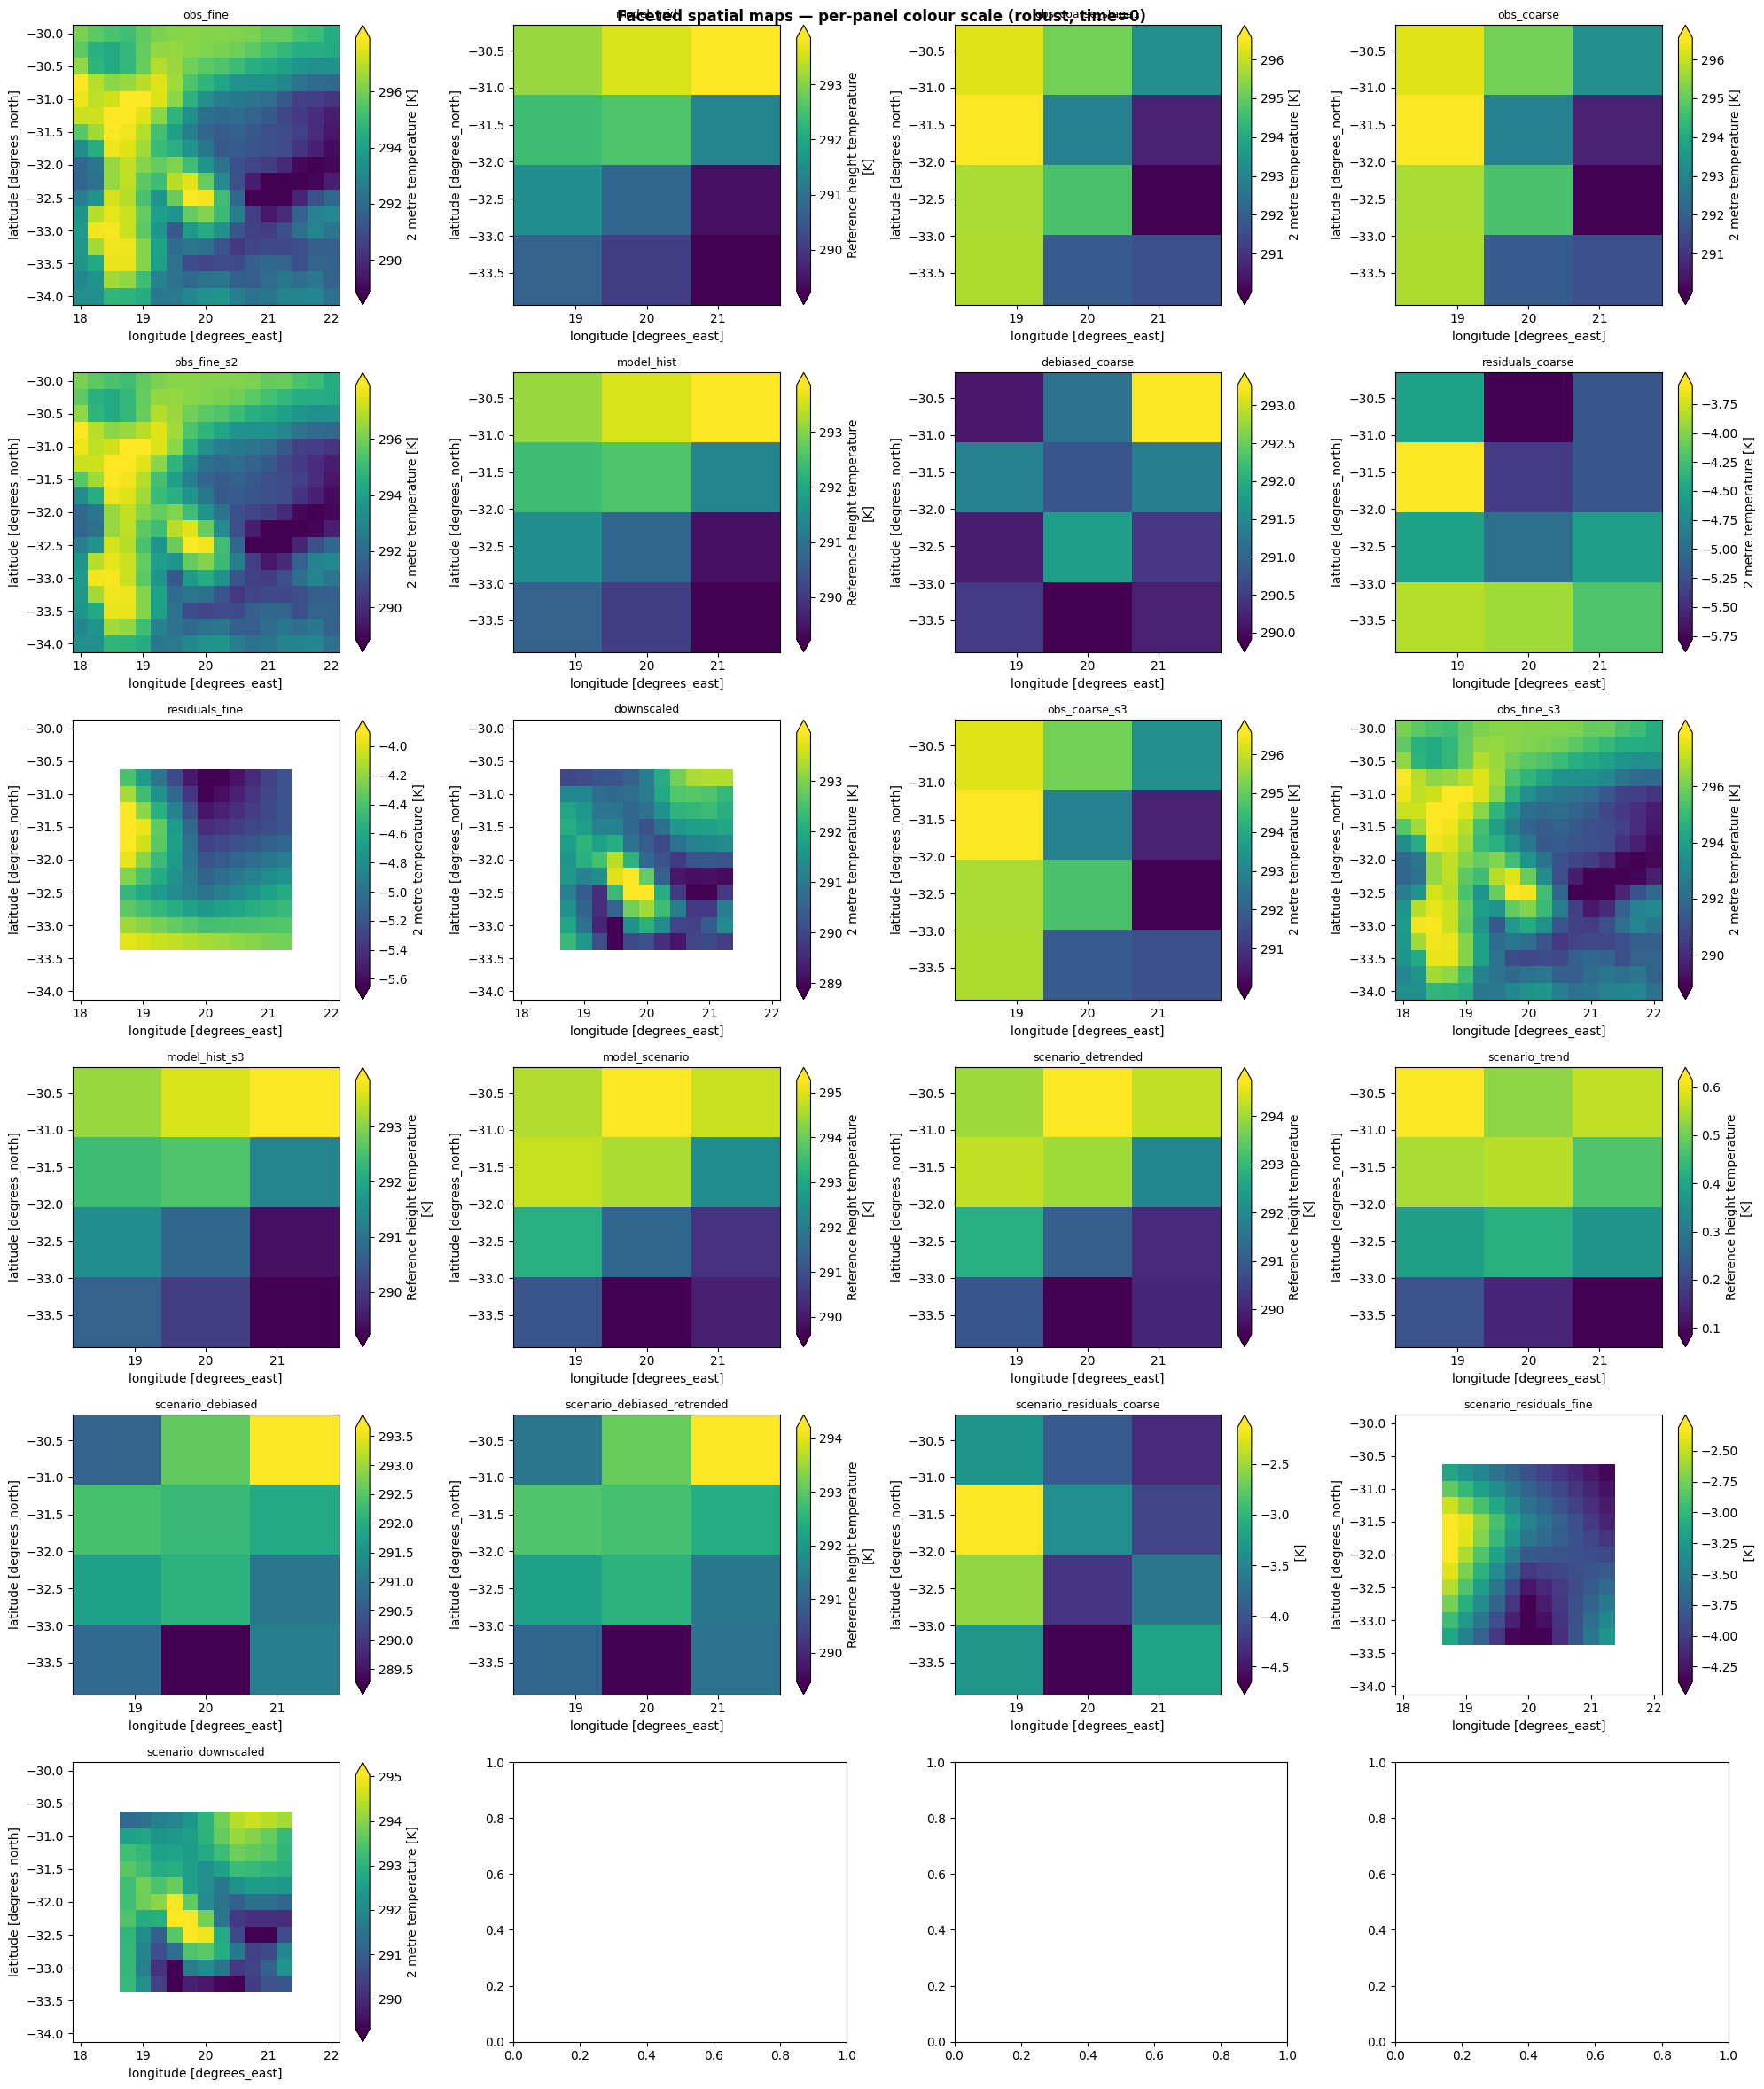

In [28]:
# ── 1. Faceted spatial maps ───────────────────────────────────────────────────
time_steps = {k: v for k, v in STEPS.items() if "time" in v.dims}
if time_steps:
    # shared vmin/vmax from obs_fine range
    ref = list(time_steps.values())[0]
    vmin = float(ref.quantile(0.02))
    vmax = float(ref.quantile(0.98))
    n = len(time_steps)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flat
    for ax, (step, da) in zip(axes_flat, time_steps.items()):
        try:
            da.isel(time=0).plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False)
        except Exception:
            da.isel(time=0).plot(ax=ax, add_colorbar=False)
        ax.set_title(step, fontsize=9)
    for ax in list(axes_flat)[len(time_steps) :]:
        ax.set_visible(False)
    fig.suptitle("Faceted spatial maps — shared colour scale (time=0)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Per-panel scaling to reveal structure hidden under shared scale
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flat
    for ax, (step, da) in zip(axes_flat, time_steps.items()):
        da.isel(time=0).plot(ax=ax, robust=True, add_colorbar=True)
        ax.set_title(step, fontsize=9)
    for ax in list(axes_flat)[len(time_steps) :]:
        ax.set_visible(False)
    fig.suptitle(
        "Faceted spatial maps — per-panel colour scale (robust, time=0)", fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No time-dim steps in STEPS yet.")

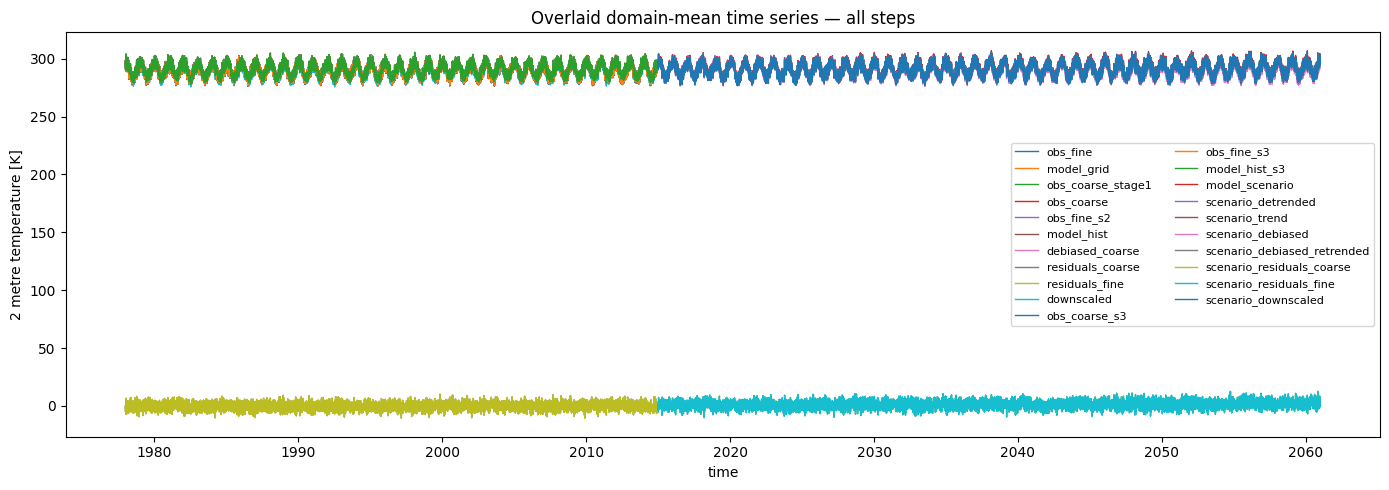

In [29]:
# ── 2. Overlaid domain-mean time series ──────────────────────────────────────
time_steps = {k: v for k, v in STEPS.items() if "time" in v.dims}
if time_steps:
    fig, ax = plt.subplots(figsize=(14, 5))
    for step, da in time_steps.items():
        da.mean(["lat", "lon"]).plot(ax=ax, label=step, linewidth=1)
    ax.legend(fontsize=8, ncol=2)
    ax.set_title("Overlaid domain-mean time series — all steps")
    plt.tight_layout()
    plt.show()

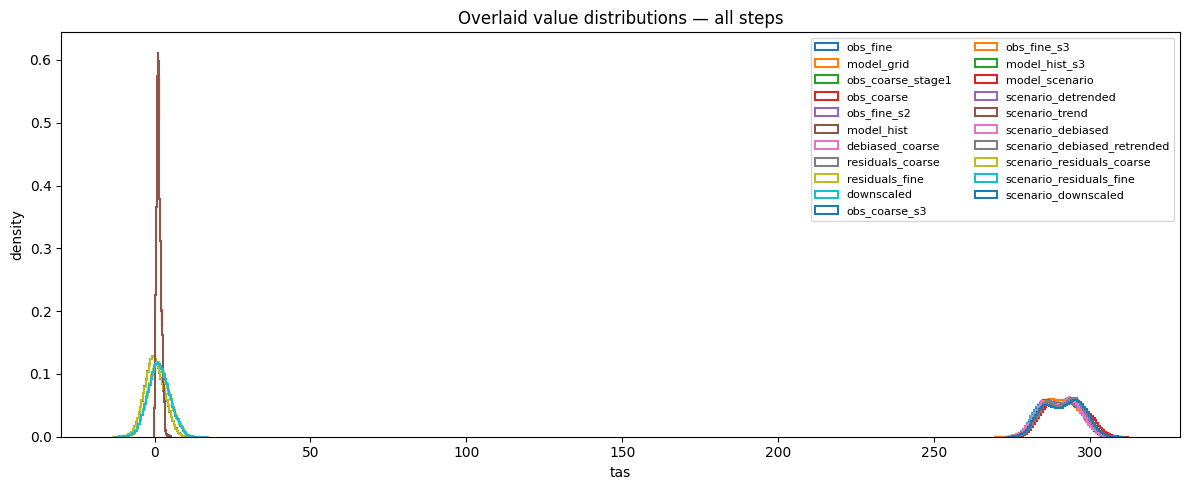

In [30]:
# ── 3. Overlaid value distributions ──────────────────────────────────────────
time_steps = {k: v for k, v in STEPS.items() if "time" in v.dims}
if time_steps:
    fig, ax = plt.subplots(figsize=(12, 5))
    for step, da in time_steps.items():
        vals = da.values.ravel()
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            ax.hist(vals, bins=60, histtype="step", density=True, label=step, linewidth=1.5)
    ax.legend(fontsize=8, ncol=2)
    ax.set_title("Overlaid value distributions — all steps")
    ax.set_xlabel(config.variable)
    ax.set_ylabel("density")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1464/3929509671.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)


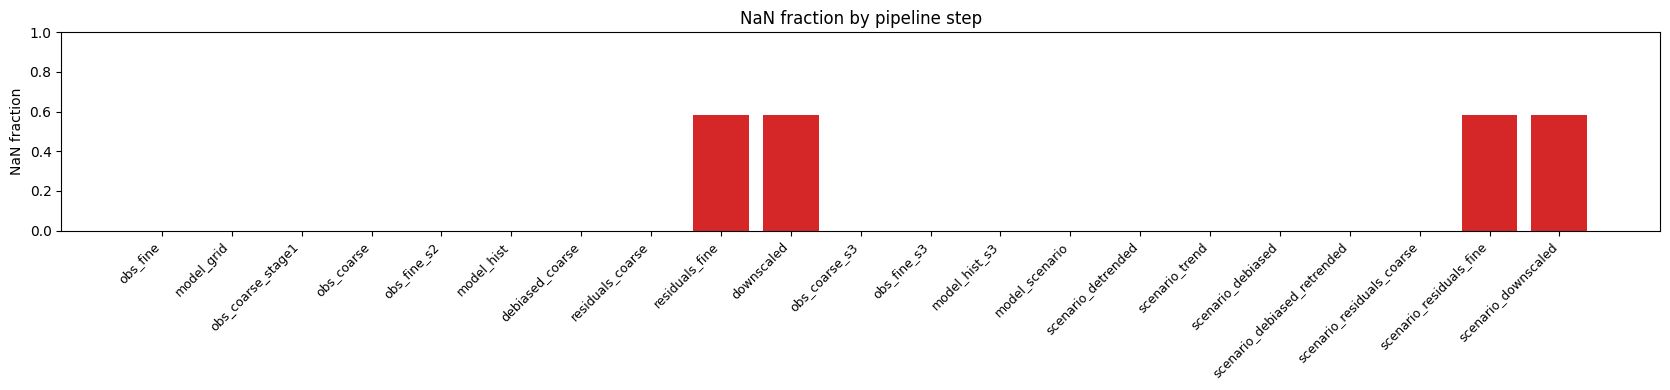

In [31]:
# ── 4. NaN-fraction by step ───────────────────────────────────────────────────
if STEP_NAN_FRACTIONS:
    labels = list(STEP_NAN_FRACTIONS.keys())
    fracs = [STEP_NAN_FRACTIONS[k] for k in labels]
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.8), 4))
    colors = ["#d62728" if f > 0 else "#2ca02c" for f in fracs]
    ax.bar(labels, fracs, color=colors)
    ax.set_ylabel("NaN fraction")
    ax.set_title("NaN fraction by pipeline step")
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("No QA results yet — run inspect() on at least one time-dim step first.")